# 1. Caso de Negocio

**Contexto:**

Con mi experiencia actual en el sector logístico y tecnológico, entiendo que la eficacia de un banco no solo reside en mover de manera eficiente el capital, sino en la capacidad de auditar su flujo de forma automatizada y con reducción de costos operativos.

**El Problema a Resolver:**

Los equipos de Compliance a menudo detectan un "vínculo crítico" (cuenta puente o entidad sospechosa) representado por una conexión específica ($u \to v$). Me planteé el reto de reconstruir la ruta completa desde el origen del capital ($o$) hasta su destino ($d$), garantizando que el algoritmo pase obligatoriamente por esta conexión para una correcta evaluación de riesgo.

# 2. Estructura de Datos y Dataset Sintético

In [1]:
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
# Definición de la estructura de datos y dataset
def crear_dataset():
    # Representamos el grafo como una lista de aristas (origen, destino, peso)
    # Escenario 1: Ruta válida que incluye la arista obligatoria (U, V)
    aristas = [
        ('O', 'A', 2), ('A', 'U', 1),
        ('U', 'V', 1), # ARISTA OBLIGATORIA
        ('V', 'B', 2), ('B', 'D', 1),
        ('O', 'C', 1), ('C', 'D', 1), # Ruta más corta global, pero NO pasa por UV
        ('X', 'Y', 5)  # Nodo aislado para caso "Sin solución"
    ]

    G = nx.DiGraph() # Grafo dirigido
    G.add_weighted_edges_from(aristas)
    return G

grafo_banco = crear_dataset()
print("Grafo creado con éxito.")

Grafo creado con éxito.


# 3. Implementación de la Solución (Algoritmo)

In [3]:
def encontrar_ruta_obligatoria(G, origen, destino, u, v):
    # Validación de los nodos en el grafo
    for nodo in [origen, destino, u, v]:
        if not G.has_node(nodo):
            return None, float('inf'), f"Error: El nodo {nodo} no existe en el dataset."

    # Validación de arista obligatoria
    if not G.has_edge(u, v):
        return None, float('inf'), f"Error: La arista obligatoria ({u}, {v}) no existe."

    try:
        # Cálculo de las sub-rutas
        ruta_1 = nx.shortest_path(G, source=origen, target=u, weight='weight')
        costo_1 = nx.shortest_path_length(G, source=origen, target=u, weight='weight')

        ruta_2 = nx.shortest_path(G, source=v, target=destino, weight='weight')
        costo_2 = nx.shortest_path_length(G, source=v, target=destino, weight='weight')

        costo_uv = G[u][v]['weight']

        # Uno las rutas evitando duplicar el nodo de contacto
        ruta_completa = ruta_1 + ruta_2
        costo_total = costo_1 + costo_uv + costo_2

        return ruta_completa, costo_total, "Éxito"

    except nx.NetworkXNoPath:
        return None, float('inf'), "No existe una trayectoria que conecte los puntos requeridos pasando por la arista obligatoria."

In [4]:
# Verificación de cumplimiento
def verificar_arista_en_ruta(ruta, u, v):
    if not ruta: return False
    # Busco algun punto de u seguido de v
    for i in range(len(ruta) - 1):
        if ruta[i] == u and ruta[i+1] == v:
            return True
    return False

# 4. Pruebas y Resultados

--- PRUEBA 1: CASO VÁLIDO ---
Resultado: Éxito
Ruta encontrada: O -> A -> U -> V -> B -> D
Costo total: 7
¿Validación técnica de arista obligatoria exitosa?: True

--- PRUEBA 2: SIN SOLUCIÓN ---
Resultado correcto: No existe una trayectoria que conecte los puntos requeridos pasando por la arista obligatoria.


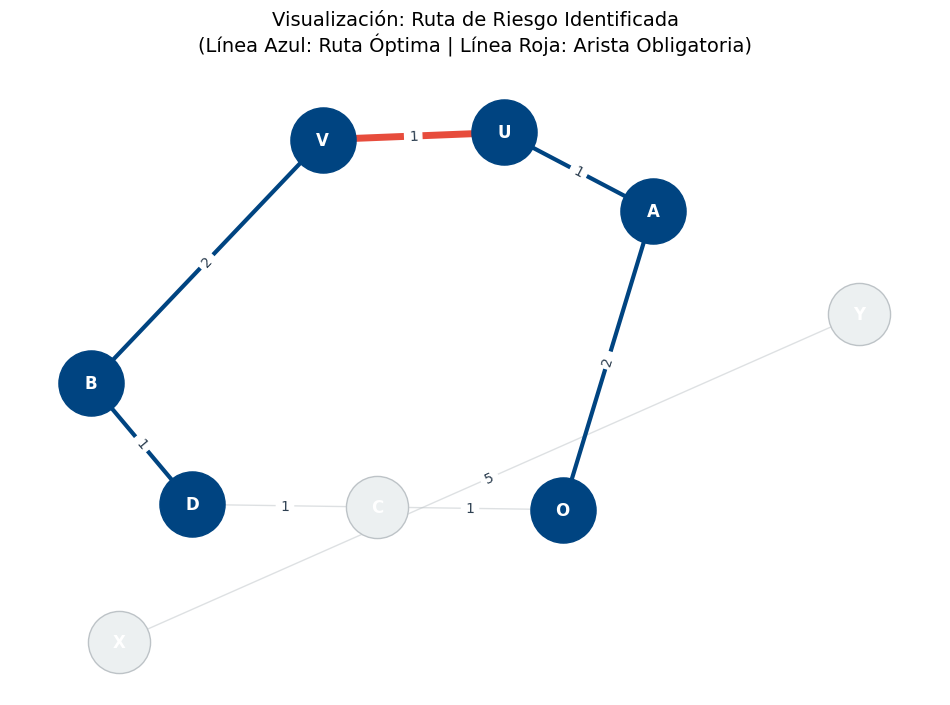

In [5]:
# Parámetros de prueba
origen_test = 'O'
destino_test = 'D'
u_obligatorio = 'U'
v_obligatorio = 'V'

print("--- PRUEBA 1: CASO VÁLIDO ---")
# Manejo 3 variables: ruta, costo y el mensaje
ruta, costo, msg = encontrar_ruta_obligatoria(grafo_banco, origen_test, destino_test, u_obligatorio, v_obligatorio)

if ruta:
    print(f"Resultado: {msg}")
    print(f"Ruta encontrada: {' -> '.join(ruta)}")
    print(f"Costo total: {costo}")
    # Validacion de arista obligatoria
    check = verificar_arista_en_ruta(ruta, u_obligatorio, v_obligatorio)
    print(f"¿Validación técnica de arista obligatoria exitosa?: {check}")
else:
    print(f"Error esperado: {msg}")

print("\n--- PRUEBA 2: SIN SOLUCIÓN ---")
ruta_inv, costo_inv, msg_inv = encontrar_ruta_obligatoria(grafo_banco, 'O', 'Y', 'U', 'V')
if not ruta_inv:
    print(f"Resultado correcto: {msg_inv}")

def visualizar_resultado(G, ruta_encontrada, u, v):
    plt.figure(figsize=(12, 8))

    # Un layout para mejora la distribucion
    pos = nx.kamada_kawai_layout(G)

    # Inserto los nodos y aristas
    nx.draw_networkx_nodes(G, pos, node_color='#ECF0F1', node_size=2000, edgecolors='#BDC3C7')
    nx.draw_networkx_edges(G, pos, edge_color='#BDC3C7', alpha=0.5, arrows=True, arrowsize=20)

    # Resalto la ruta completa
    if ruta_encontrada:
        path_edges = list(zip(ruta_encontrada, ruta_encontrada[1:]))
        nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='#004481', width=3)
        nx.draw_networkx_nodes(G, pos, nodelist=ruta_encontrada, node_color='#004481', node_size=2200)

    # Resalto la arista obligatoria (rojo)
    nx.draw_networkx_edges(G, pos, edgelist=[(u, v)], edge_color='#E74C3C', width=5)

    # Resalto contraste de las etiquetas
    nx.draw_networkx_labels(G, pos, font_size=12, font_family='sans-serif', font_weight='bold',
                            font_color='black' if not ruta_encontrada else 'white')

    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='#2C3E50', font_size=10)

    plt.title("Visualización: Ruta de Riesgo Identificada\n(Línea Azul: Ruta Óptima | Línea Roja: Arista Obligatoria)",
              fontsize=14, pad=20)
    plt.axis('off')
    plt.show()

# resultados:
visualizar_resultado(grafo_banco, ruta, u_obligatorio, v_obligatorio)

In [6]:
import pandas as pd
from google.colab import files

# Extraemos las aristas del grafo para convertirlos en tabla
datos_aristas = []
for u, v, data in grafo_banco.edges(data=True):
    datos_aristas.append({
        'Origen': u,
        'Destino': v,
        'Costo_Riesgo': data.get('weight', 0)
    })

# Creamos el DataFrame
df_final = pd.DataFrame(datos_aristas)

# Se guarda y descarga
df_final.to_csv('transferencias_sinteticas.csv', index=False)
files.download('transferencias_sinteticas.csv')

print("¡Archivo CSV generado y descargado con éxito!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

¡Archivo CSV generado y descargado con éxito!
